# Atividade Prática: CadÚnico

In [1]:
from pyspark.sql import SparkSession

In [2]:
spark = (SparkSession.builder.appName("Analise Cad Unico")
        .config('spark.driver.memory', '16g')  
        .config('spark.driver.maxResultSize', '4g')
        .getOrCreate()
)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/10/06 14:12:37 WARN Utils: Your hostname, snes-6-phishmon, resolves to a loopback address: 127.0.1.1; using 10.233.51.6 instead (on interface enp5s0)
26/10/06 14:12:37 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/mnt/shared/vitoramorim/UFSJ/TecnologiasDataScience/PandasIBGE/.venv/lib/python3.12/site-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/10/06 14:12:42 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [9]:
df = spark.read.csv("Data/PESSOA_2018.csv", header=True, inferSchema=True, sep=';')

In [10]:
from pyspark.sql.functions import col, avg, stddev, percentile_approx, to_date, lit, year, when, count as _count, coalesce, lit, sum as _sum
from pyspark.sql.window import Window

import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df.columns

['CD_IBGE_CADASTRO',
 'CO_FAMILIAR_FAM',
 'MARC_PBF',
 'CO_CHV_NATURAL_PESSOA',
 'IN_TRABALHO_INFANTIL_PESSOA',
 'CO_SEXO_PESSOA',
 'DT_NASC_PESSOA',
 'CO_PARENTESCO_RF_PESSOA',
 'CO_RACA_COR_PESSOA',
 'CO_DEFICIENCIA_MEMB',
 'CO_SABE_LER_ESCREVER_MEMB',
 'IN_FREQUENTA_ESCOLA_MEMB',
 'CO_CURSO_FREQUENTA_MEMB',
 'CO_ANO_SERIE_FREQUENTA_MEMB',
 'CO_CURSO_FREQ_PESSOA_MEMB',
 'CO_ANO_SERIE_FREQUENTOU_MEMB',
 'CO_CONCLUIU_FREQUENTOU_MEMB',
 'CO_TRABALHOU_SEMANA_MEMB',
 'CO_AGRICULTURA_TRAB_MEMB',
 'VL_REMUNER_EMPREGO_MEMB',
 'VL_RENDA_BRUTA_12_MESES_MEMB',
 'VL_RENDA_DOACAO_MEMB',
 'VL_RENDA_APOSENT_MEMB',
 'VL_RENDA_SEGURO_DESEMP_MEMB',
 'VL_RENDA_PENSAO_ALIMEN_MEMB',
 'VL_RENDA_OUTRAS_MEMB']

## Etapa 1: Analise Demográfica e Mercado de Trabalho

### Distribuicao de idade das pessoas registradas no CadUnico agrupando por sexo/genero e cor/raca.

**Calcula as idades**

In [5]:
# Adiciona coluna nova para idade
df = df.withColumn("DT_NASC_FORMATADA", to_date(col("DT_NASC_PESSOA")))
df = df.withColumn("IDADE", lit(2018) - year(col("DT_NASC_FORMATADA")))

# Remove idades inconsistentes
df = df.filter((col("IDADE").isNotNull()) & (col("IDADE") >= 0) & (col("IDADE") <= 120))

**Agrupamento por sexo/genero e cor/raca**

CO_SEXO_PESSOA (sexo/genero):  
    - 1 (masculino)  
    - 2 (feminino)  
CO_RACA_COR_PESSOA (cor/raca):  
    - 1 (branca),  
    - 2 (preta),  
    - 3 (amarela),  
    - 4 (parda),  
    - 5 (indigena)  

In [6]:
dist_idade = df.groupBy("CO_SEXO_PESSOA", "CO_RACA_COR_PESSOA").agg(
    avg("IDADE").alias("Media"),
    percentile_approx("IDADE", 0.5).alias("Mediana"),
    stddev("IDADE").alias("DesvioPadrao")
).orderBy("CO_SEXO_PESSOA", "CO_RACA_COR_PESSOA")

dist_idade.show()

+--------------+------------------+------------------+-------+------------------+
|CO_SEXO_PESSOA|CO_RACA_COR_PESSOA|             Media|Mediana|      DesvioPadrao|
+--------------+------------------+------------------+-------+------------------+
|             1|              NULL| 55.51458282057593|     62| 18.67607065946442|
|             1|                 1|27.586211974167217|     20|22.117301229948477|
|             1|                 2| 31.71217787972735|     28|21.012420407407568|
|             1|                 3|27.200271519539708|     20| 21.95743029092225|
|             1|                 4|25.578828265938938|     19| 20.03588426867681|
|             1|                 5|20.873706310457308|     16|17.016989874435104|
|             2|              NULL| 47.63195691202873|     46| 18.42699729368654|
|             2|                 1| 31.29263943721671|     29| 21.45472410211747|
|             2|                 2| 34.75895707825514|     34|19.090036022703888|
|             2|

### Visualização

In [7]:
dist_idade_pandas = dist_idade.toPandas()

map_genero = {1: "Masculino", 2: "Feminino"}
map_raca = {1: "Branca", 2: "Preta", 3: "Amarela", 4: "Parda", 5: "Indígena"}

dist_idade_pandas["Genero"] = dist_idade_pandas["CO_SEXO_PESSOA"].map(map_genero)
dist_idade_pandas["Raca_Cor"] = dist_idade_pandas["CO_RACA_COR_PESSOA"].map(map_raca).fillna("Nao Declarou")

/mnt/shared/vitor/UFSJ/TecnologiasDataScience/PandasIBGE/.venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


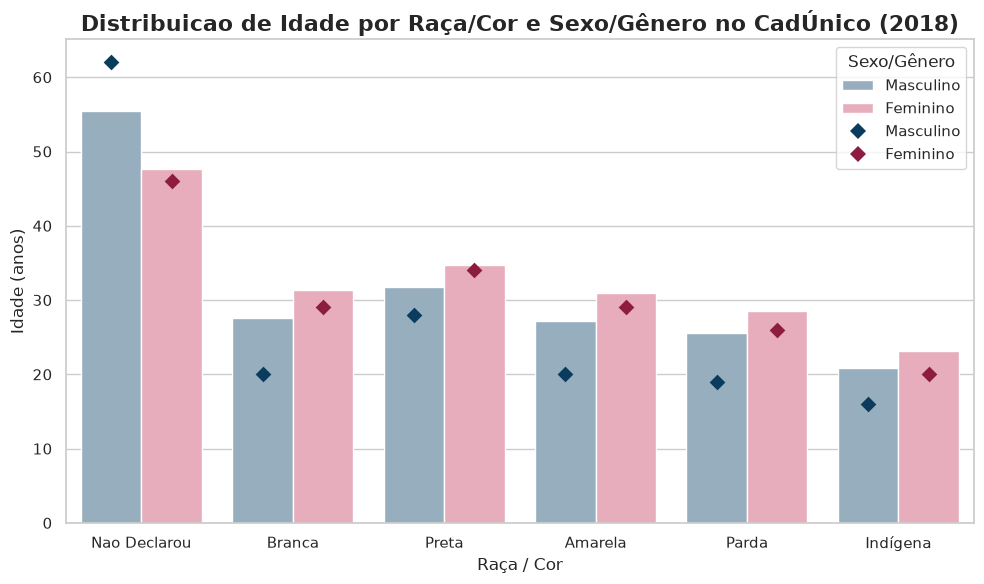

In [8]:
plt.figure(figsize=(10, 6))
sns.set_theme(style='whitegrid')

# Barras = média
ax = sns.barplot(
    data=dist_idade_pandas,
    x="Raca_Cor",
    y="Media",
    hue="Genero",
    palette=["#90afc5", "#f1a3b8"],
)

sns.stripplot(
    data=dist_idade_pandas,
    x="Raca_Cor",
    y="Mediana",
    hue="Genero",
    dodge=True,
    marker='D',
    size=8,
    palette=["#0b3c5d", "#8c1d40"],
    ax=ax
)

plt.title("Distribuicao de Idade por Raça/Cor e Sexo/Gênero no CadÚnico (2018)", fontsize=16, weight='bold')
plt.xlabel("Raça / Cor", fontsize=12)
plt.ylabel("Idade (anos)", fontsize=12)
plt.legend(title="Sexo/Gênero")
plt.tight_layout()
plt.show()

### Taxa proporcional de trabalhadores informais e formais entre os individuos em idade ativa

In [9]:
# idade ativa: 18 a 65 anos
df_idade_ativa = df.filter((col("IDADE") >= 18) & ((col("IDADE") <= 65)))

# assume a formalidade a partir das colunas que temos
df_trabalho = df_idade_ativa.withColumn(
    "TIPO_TRABALHO",
    # Trabalhadores formais
    when(
        col("VL_REMUNER_EMPREGO_MEMB") > 0, # Recebeu remuneracao do trabalho principal no mes anterior
        "Formal"
    )
    # Trabalhadores informais 
    .when(
        (col("CO_TRABALHOU_SEMANA_MEMB") == 1) | # Trabalhou na semana passada
        (col("CO_AGRICULTURA_TRAB_MEMB") == 1) | # Realizou atividade rural
        (col("VL_RENDA_BRUTA_12_MESES_MEMB") > 0), # Recebeu rendimentos variaveis nos ultimos 12 meses
        "Informal"
    )
    # Desempregados
    .otherwise(
        "Desempregado"
    )
)

In [11]:
# filtra somente pelas pessoas que trabalham
df_trabalhadores = df_trabalho.filter(col("TIPO_TRABALHO").isin(["Formal", "Informal"]))

Calcula a taxa proporcional

In [12]:

total_trabalhadores = df_trabalhadores.count() 

proporcao_trabalho = df_trabalhadores.groupBy("TIPO_TRABALHO"
    ).agg(
        _count("*").alias("Quantidade")
    ).withColumn(
        "Taxa_Proporcional",
        col("Quantidade") / total_trabalhadores
    )

proporcao_trabalho.show()

+-------------+----------+-------------------+
|TIPO_TRABALHO|Quantidade|  Taxa_Proporcional|
+-------------+----------+-------------------+
|     Informal|   1571606|0.08889007287872196|
|       Formal|  16108726|  0.911109927121278|
+-------------+----------+-------------------+



### Visualização

In [13]:
df_trabalho = proporcao_trabalho.toPandas()

df_trabalho['Percentual'] = df_trabalho['Taxa_Proporcional'] * 100

/mnt/shared/vitor/UFSJ/TecnologiasDataScience/PandasIBGE/.venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


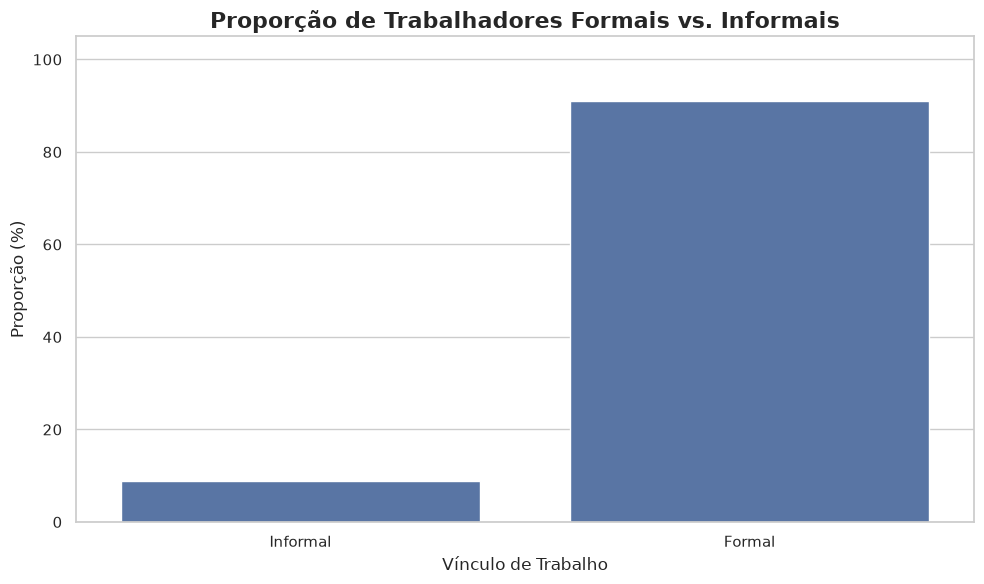

In [15]:
sns.set_theme(style='whitegrid')
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=df_trabalho,
    x="TIPO_TRABALHO",
    y='Percentual'
)

plt.title("Proporção de Trabalhadores Formais vs. Informais", fontsize=16, weight='bold')
plt.xlabel('Vínculo de Trabalho', fontsize=12)
plt.ylabel('Proporção (%)', fontsize=12)
plt.ylim(0, 105)

plt.tight_layout()
plt.show()

### Renda media do trabalho individual por nivel de instrucao/escolaridade da pessoa

In [16]:
# descarta pessoas sem remuneracao no ultimo mes anterior a pesquisa
df_renda = df.filter(
    (col("VL_REMUNER_EMPREGO_MEMB").isNotNull()) & 
    (col("VL_REMUNER_EMPREGO_MEMB") > 0)
)

df_escolaridade = df_renda.withColumn(
    "NIVEL_ESCOLARIDADE",
    # Sem instrucao / Analfabetos
    when(
        (col("CO_SABE_LER_ESCREVER_MEMB") == 2) | # Nao sabe ler/escrever
        col("CO_CURSO_FREQ_PESSOA_MEMB").isin([1, 2, 3, 14, 15]), # Cursos basicos
        "1 - Sem Instrucao"
    )
    # Fundamental Incompleto 
    .when(
        col("CO_CURSO_FREQ_PESSOA_MEMB").isin([4, 10]) |  # Cursos de fundamental series iniciais 
        (
            col("CO_CURSO_FREQ_PESSOA_MEMB").isin([5, 6, 7, 11]) & # Cursos de fundamental series finais
            (col("CO_CONCLUIU_FREQUENTOU_MEMB") == 2) # Nao concluiu
        ),
        "2 - Fundamental Incompleto"
    )
    # Fundamental Completo 
    .when(
        col("CO_CURSO_FREQ_PESSOA_MEMB").isin([5, 6, 7, 11]) & # Cursos de fundamental series finais
        (col("CO_CONCLUIU_FREQUENTOU_MEMB") == 1), # Concluiu
        "3 - Fundamental Completo"
    )
    # Medio Incompleto
    .when(
        col("CO_CURSO_FREQ_PESSOA_MEMB").isin([8, 9, 12]) & # Cursos de ensino médio
        (col("CO_CONCLUIU_FREQUENTOU_MEMB") == 2), # Nao concluiu
        "4 - Medio Incompleto"
    )
    # Medio Completo
    .when(
        col("CO_CURSO_FREQ_PESSOA_MEMB").isin([8, 9, 12]) & # Cursos de ensino médio
        (col("CO_CONCLUIU_FREQUENTOU_MEMB") == 1), # Concluiu
        "5 - Medio Completo"
    )
    # Curso Superior
    .when(
        col("CO_CURSO_FREQ_PESSOA_MEMB") == 13,
        "6 - Superior"
    )
    .otherwise("7 - Outros")
)

renda_por_escolaridade = df_escolaridade.groupBy("NIVEL_ESCOLARIDADE").agg(
    avg("VL_REMUNER_EMPREGO_MEMB").alias("Renda_Media"),
    _count("*").alias("Quantidade")
).orderBy("NIVEL_ESCOLARIDADE")

renda_por_escolaridade.show(truncate=False)

+--------------------------+------------------+----------+
|NIVEL_ESCOLARIDADE        |Renda_Media       |Quantidade|
+--------------------------+------------------+----------+
|1 - Sem Instrucao         |330.11667999820776|1361433   |
|2 - Fundamental Incompleto|450.24610999942746|6445179   |
|3 - Fundamental Completo  |546.2350482197992 |1400151   |
|4 - Medio Incompleto      |532.7567052556627 |1526601   |
|5 - Medio Completo        |686.8184343483401 |4426834   |
|6 - Superior              |1362.6053217372053|415541    |
|7 - Outros                |583.4048111141527 |730600    |
+--------------------------+------------------+----------+



### Visualização

In [17]:
df_escolaridade = renda_por_escolaridade.toPandas()

/mnt/shared/vitor/UFSJ/TecnologiasDataScience/PandasIBGE/.venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


/tmp/ipykernel_436615/3489362198.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barras = sns.barplot(


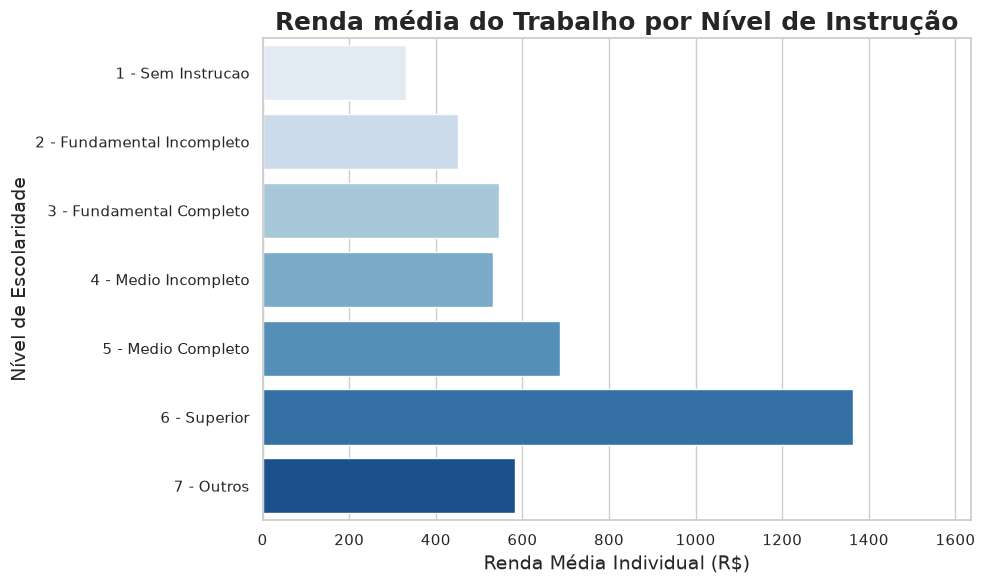

In [18]:
sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(10, 6))

paleta = sns.color_palette('Blues_r', n_colors=len(df_escolaridade))[::-1]

barras = sns.barplot(
    data=df_escolaridade,
    x="Renda_Media",
    y="NIVEL_ESCOLARIDADE",
    palette=paleta,
    ax=ax
)

ax.set_title("Renda média do Trabalho por Nível de Instrução", fontsize=18, weight='bold')
ax.set_xlabel("Renda Média Individual (R$)", fontsize=14)
ax.set_ylabel("Nível de Escolaridade", fontsize=14)
ax.set_xlim(0, df_escolaridade["Renda_Media"].max() * 1.2)

plt.tight_layout()
plt.show()

## Etapa 2: Análise do Perfil de Trabalho e Escolaridade

### Agrupa os cadastrados por faixa etária e determina a proporção de indivíduos que declaram possuir trabalho remunerado em cada grupo

In [19]:
df_faixa_etaria = df.withColumn(
    "FAIXA_ETARIA",
    # Criancas 
    when(
        col("IDADE") <= 17, 
        "1 - Criancas e Adolescentes"
    )
    # Jovens
    .when(
        (col("IDADE") >= 18) &
        (col("IDADE") <= 29),
        "2 - Jovens"
    )
    # Adultos
    .when(
        (col("IDADE") >= 30) &
        (col("IDADE") <= 59),
        "3 - Adultos"
    )
    # Idosos
    .when(
        col("IDADE") >= 60,
        "4 - Idosos"
    )
    .otherwise("Erro")
).withColumn(
    "POSSUI_TRABALHO",
    when(
        (col("VL_REMUNER_EMPREGO_MEMB") > 0) | # Recebeu remuneracao no mes anterior
        (col("VL_RENDA_BRUTA_12_MESES_MEMB") > 0) | # Teve renda nos ultimos 12 meses
        (col("CO_TRABALHOU_SEMANA_MEMB") == 1), # Trabalhou na semana de referencia
        1
    ).otherwise(0)
)

# agrupa por faixa etaria
proporcao_por_faixa_etaria = df_faixa_etaria.groupBy("FAIXA_ETARIA").agg(
    _count("*").alias("Pessoas"),
    avg("POSSUI_TRABALHO").alias("Proporcao_Trabalho_Remunerado")
).orderBy("FAIXA_ETARIA")

proporcao_por_faixa_etaria.show(truncate=False)

+---------------------------+--------+-----------------------------+
|FAIXA_ETARIA               |Pessoas |Proporcao_Trabalho_Remunerado|
+---------------------------+--------+-----------------------------+
|1 - Criancas e Adolescentes|28208425|0.0020762945822037212        |
|2 - Jovens                 |14331010|0.30189170198053034          |
|3 - Adultos                |24149882|0.521498283097201            |
|4 - Idosos                 |6944936 |0.12118225423531621          |
+---------------------------+--------+-----------------------------+



### Visualização

In [20]:
df_faixa_etaria = proporcao_por_faixa_etaria.toPandas()

df_faixa_etaria['Percentual'] = df_faixa_etaria['Proporcao_Trabalho_Remunerado'] * 100

/mnt/shared/vitor/UFSJ/TecnologiasDataScience/PandasIBGE/.venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


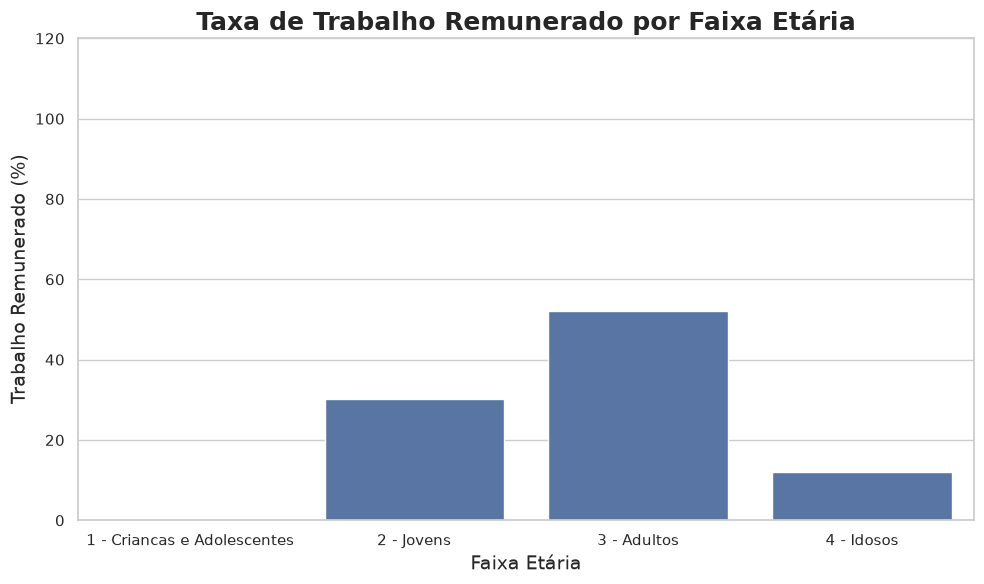

In [21]:
sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=df_faixa_etaria,
    x="FAIXA_ETARIA",
    y="Percentual",
    ax=ax
)

ax.set_title("Taxa de Trabalho Remunerado por Faixa Etária", fontsize=18, weight='bold')
ax.set_xlabel('Faixa Etária', fontsize=14)
ax.set_ylabel("Trabalho Remunerado (%)", fontsize=14)
ax.set_ylim(0, 120)

plt.tight_layout()
plt.show()

### Percentual de idosos com deficiência (PCD) dentro de cada faixa de renda familiar per capita

In [22]:
# adiciona coluna renda individual
# substitui valores nulos por 0
df_renda = df.withColumn(
    "RENDA_TOTAL_INDIVIDUAL",
    coalesce(col("VL_REMUNER_EMPREGO_MEMB"), lit(0)) +
    coalesce(col("VL_RENDA_DOACAO_MEMB"), lit(0)) +
    coalesce(col("VL_RENDA_APOSENT_MEMB"), lit(0)) +
    coalesce(col("VL_RENDA_SEGURO_DESEMP_MEMB"), lit(0)) +
    coalesce(col("VL_RENDA_PENSAO_ALIMEN_MEMB"), lit(0)) +
    coalesce(col("VL_RENDA_OUTRAS_MEMB"), lit(0))
)

# define a janela de particao por grupo familiar
janela_familia = Window.partitionBy("CO_FAMILIAR_FAM")

# adiciona coluna de renda per capita
df_familia = df_renda.withColumn(
    "RENDA_TOTAL_FAMILIAR",
    _sum("RENDA_TOTAL_INDIVIDUAL").over(janela_familia)
).withColumn(
    "QTD_MEMBROS_FAMILIA",
    _count("*").over(janela_familia)
).withColumn(
    "RENDA_PER_CAPITA",
    col("RENDA_TOTAL_FAMILIAR") / col("QTD_MEMBROS_FAMILIA")
)

# cria faixas de renda familiar per capita e flag binaria de PCD
df_pcd = df_familia.withColumn(
    "FAIXA_RENDA_PER_CAPITA",
    when(
        (col("RENDA_PER_CAPITA") <= 109), 
        "1 - Ate R$109,00"
    )
    .when(
        (col("RENDA_PER_CAPITA") > 109) & 
        (col("RENDA_PER_CAPITA") <= 218),
        "2 - De R$109,01 ate R$218,00"
    )
    .when(
        (col("RENDA_PER_CAPITA") > 218) &
        (col("RENDA_PER_CAPITA") <= 477),
        "3 - De R$218,01 ate 1/2 Salario Minimo"
    )
    .otherwise("4 - Acima de 1/2 Salario Minimo")
).withColumn(
    "FLAG_PCD",
    when(
        col("CO_DEFICIENCIA_MEMB") == 1, 
        1
    )
    .otherwise(0)
)

percentual_pcd_faixa_renda = df_pcd.groupBy("FAIXA_RENDA_PER_CAPITA").agg(
    _count("*").alias("Total_Pessoas"),
    _sum("FLAG_PCD").alias("Total_PCD"),
    (avg("FLAG_PCD") * 100).alias("Percentual_PCD")
).orderBy("FAIXA_RENDA_PER_CAPITA")

percentual_pcd_faixa_renda.show(truncate=False)

+--------------------------------------+-------------+---------+------------------+
|FAIXA_RENDA_PER_CAPITA                |Total_Pessoas|Total_PCD|Percentual_PCD    |
+--------------------------------------+-------------+---------+------------------+
|1 - Ate R$109,00                      |36430768     |670805   |1.8413144625444073|
|2 - De R$109,01 ate R$218,00          |11407864     |349332   |3.062203406351969 |
|3 - De R$218,01 ate 1/2 Salario Minimo|15513739     |1193477  |7.6930326080643745|
|4 - Acima de 1/2 Salario Minimo       |10281882     |1386411  |13.484019754360146|
+--------------------------------------+-------------+---------+------------------+



### Visualização Gráfica

In [24]:
pdf_pcd = percentual_pcd_faixa_renda.toPandas()

/mnt/shared/vitor/UFSJ/TecnologiasDataScience/PandasIBGE/.venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


/tmp/ipykernel_436615/4071645342.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


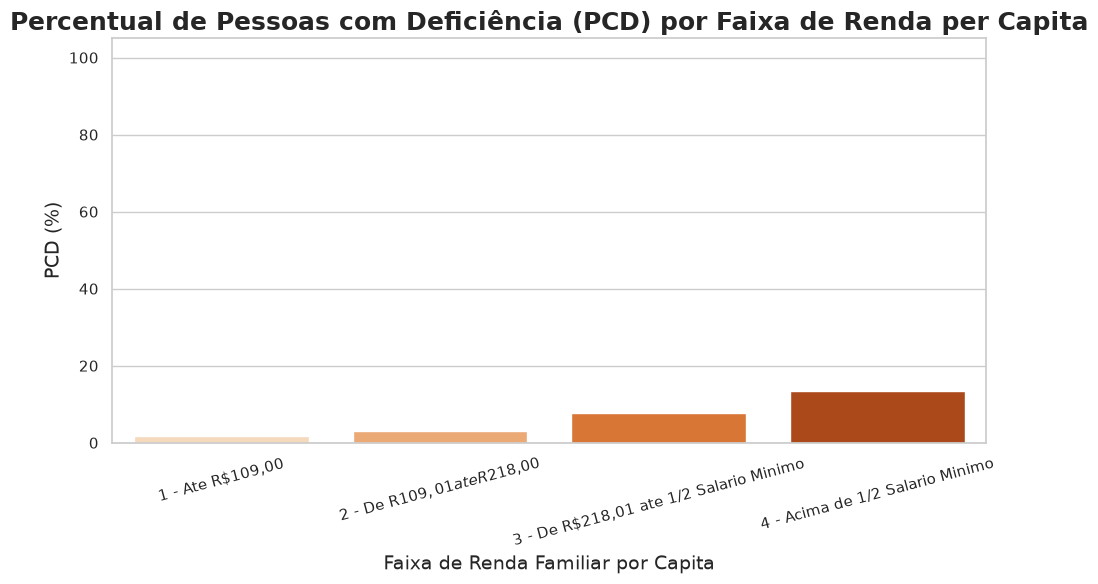

In [26]:
sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(10, 6))

paleta = sns.color_palette("Oranges_r", n_colors=len(pdf_pcd))[::-1]

sns.barplot(
    data=pdf_pcd,
    x="FAIXA_RENDA_PER_CAPITA",
    y='Percentual_PCD',
    palette=paleta,
    ax=ax
)

ax.set_title("Percentual de Pessoas com Deficiência (PCD) por Faixa de Renda per Capita", fontsize=18, weight='bold')
ax.set_xlabel("Faixa de Renda Familiar por Capita", fontsize=14)
ax.set_ylabel("PCD (%)", fontsize=14)
ax.set_ylim(0, 105)
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## Etapa 3: Proposta de Enriquecimento de Dados